<a href="https://colab.research.google.com/github/Byron-Williams/Project-1/blob/main/Ch12_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-3-60472c77a2ec>:23: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im)


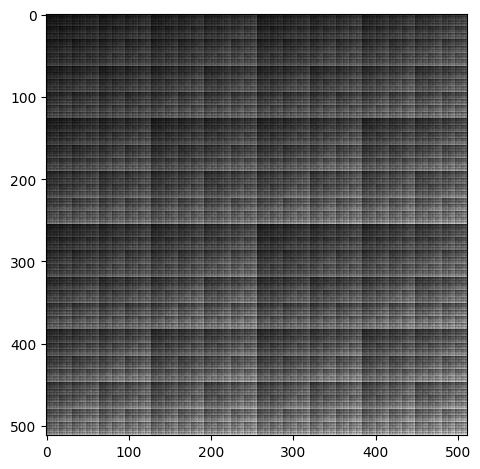

In [3]:
# Multifractal image
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, io, img_as_ubyte
p1, p2, p3, p4 = 0.1, 0.2, 0.3, 0.4
p = [[p1, p2], [p3, p4]]
for k in range(1, 9, 1):
  M = np.zeros([2**(k+1), 2**(k+1)])
  M.tolist()
  for i in range(2**k):
    for j in range(2**k):
      M[i][j] = p1*p[i][j]
      M[i, j+2**k] = p2*p[i][j]
      M[i+2**k, j] = p3*p[i][j]
      M[i+2**k, j+2**k] = p4*p[i][j]
  p = M
M = exposure.adjust_gamma(M, 0.2)
plt.imshow(M, cmap="gray", interpolation="nearest")
im = np.array(M, dtype="float64")
im = exposure.rescale_intensity(im, out_range="float")
im = img_as_ubyte(im)
io.imsave("Multifractal.png", im)
io.imshow(im)

<ipython-input-4-f96fb65ac60b>:11: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(peppers)


Image Dimensions= (700, 700, 3)
There are 77,425 yellow pixels


<Figure size 640x480 with 0 Axes>

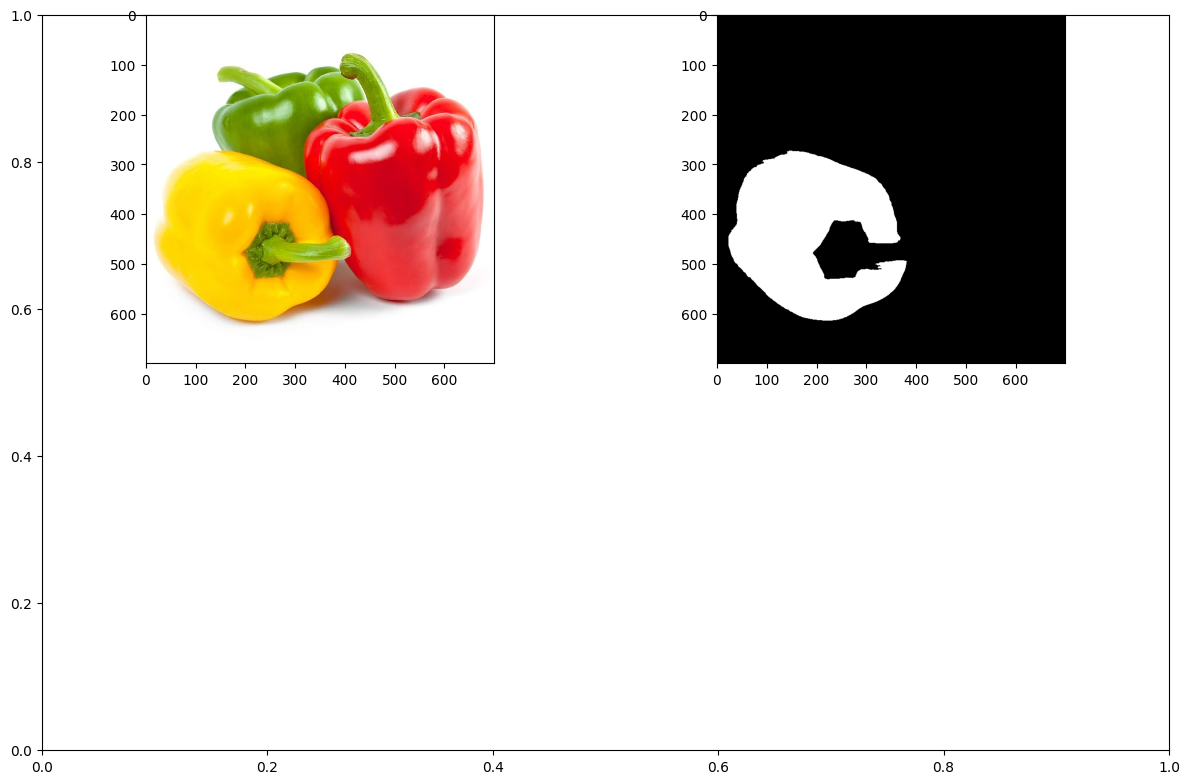

In [4]:
# 12.2: Counting yellow pixels in an image.
# Load peppers.jpeg into the Google Colab folder on the left.
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology
peppers = io.imread("peppers.jpeg")
plt.figure()
plt.subplots(figsize=(12, 8))
plt.subplot(221)
io.imshow(peppers)
print("Image Dimensions=" , peppers.shape)
Yellow = np.zeros((700,700))
for i in range(700):
    for j in range(700):
        if peppers[j,i,0]>230 and peppers[j,i,1]>130 \
            and peppers[j,i,2]<145:
            Yellow[j,i]=int(1)
        else:
            Yellow[j,i]=int(0)
plt.subplot(222)
# The array has to be Boolean.
Yellow = Yellow.astype(bool)
# Remove objects with area less than 20000 pixels.
Yellow = morphology.remove_small_objects(Yellow, 20000)
plt.imshow(Yellow , cmap="gray")
pixel_count = int(np.sum(Yellow))
print("There are {:,} yellow pixels".format(pixel_count))

There are 38,895 clusters of white pixels
There are 106 clusters of cells:
[  73   15  147  255  885  650  197 1065  228   92   99   92   90   39
   91  877  691  502  173  366 1081   44 2417   17  225  109  118   75
  174  282  632   45  472  289  128  129   13  375  218   97 1159  284
 1560  324 1341  346  532  206  114  377 3264  161  263  187   94  133
  221  136  214  161 1065  104   92  289   81   92   54  916  451  444
  177 1594 1073  179  158  106  181  365  867  838   44  417  336   77
  308  383  194  157   48   26   71  180   22   93  218 1024   97  270
  181   66  241   50  221  239   62  100]


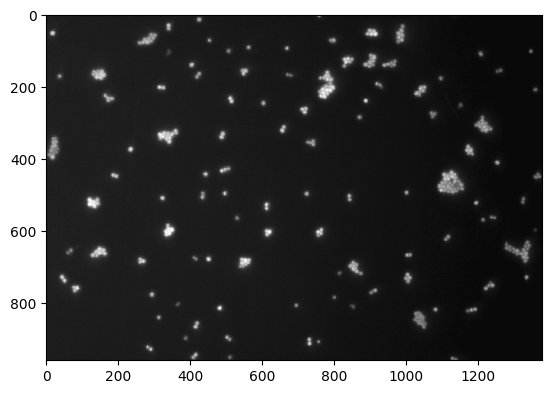

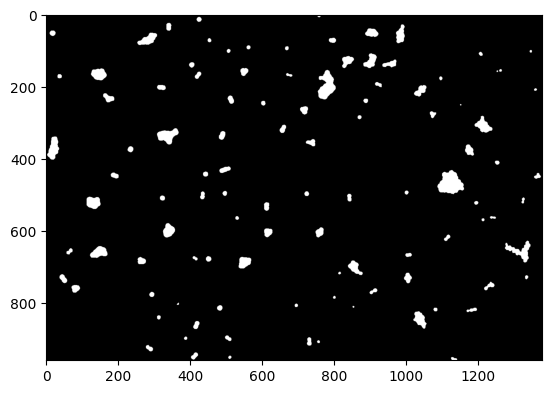

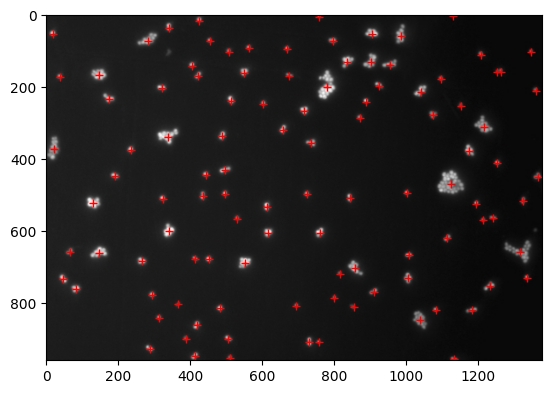

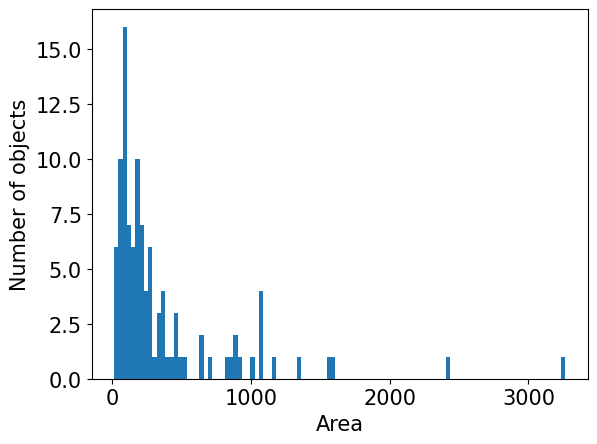

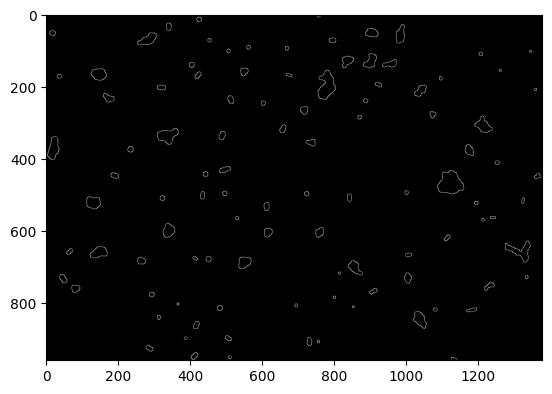

In [5]:
# Analysis on microbes
import matplotlib.pyplot as plt
from skimage import io, measure
import numpy as np
from skimage.measure import regionprops
from scipy import ndimage
from skimage import feature
microbes_img = io.imread("Microbes.png")
fig1 = plt.figure() # original image
plt.imshow(microbes_img, cmap="gray", interpolation="nearest")
width, height, _ = microbes_img.shape
fig2 = plt.figure() # binary image
binary = np.zeros((width, height))
for i, row in enumerate(microbes_img):
  for j, pixel in enumerate(row):
    if pixel[0] > 80:
      binary[i, j] = 1
plt.imshow(binary, cmap="gray")
print("There are {:,} clusters of white pixels".format(int(np.sum(binary))))
blobs = np.where(binary>0.5, 1, 0)
labels, no_objects = ndimage.label(blobs)
props = regionprops(blobs)
print("There are {:,} clusters of cells:".format(no_objects))
# fig3. Centroids of the clusters.
object_labels = measure.label(binary)
some_props = measure.regionprops(object_labels)
fig,ax = plt.subplots(1,1)
# plt.axis('off')
ax.imshow(microbes_img, cmap="gray")
centroids = np.zeros(shape=(len(np.unique(labels)),2))
for i, prop in enumerate(some_props):
  my_centroid = prop.centroid
  centroids[i,:] = my_centroid
  ax.plot(my_centroid[1], my_centroid[0], 'r+')
# print(centroids)
fig4 = plt.figure() # histogram of data
labeled_areas = np.bincount(labels.ravel())[1:]
print(labeled_areas)
plt.hist(labeled_areas, bins=no_objects)
plt.xlabel("Area", fontsize=15)
plt.ylabel("Number of objects", fontsize=15)
plt.tick_params(labelsize=15)
fig5 = plt.figure() # Canny edge detector
edges = feature.canny(binary, sigma=2, low_threshold=0.5, high_threshold=1)
plt.imshow(edges, cmap=plt.cm.gray)
plt.show()
